In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [21]:
BASE_PATH = "/content/drive/MyDrive/electricity-load-system"

file_path = f"{BASE_PATH}/data/processed/daily_consumption.csv"

df = pd.read_csv(file_path, parse_dates=["datetime"])
df = df.dropna().reset_index(drop=True)

df.head()


,datetime,Global_active_power
0,2006-12-16,3.053475
1,2006-12-17,2.354486
2,2006-12-18,1.530435
3,2006-12-19,1.157079
4,2006-12-20,1.545658


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["scaled_power"] = scaler.fit_transform(
    df[["Global_active_power"]]
)

In [23]:
def create_sequences(data, window_size=14):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 14

X, y = create_sequences(df["scaled_power"].values, WINDOW_SIZE)

print(X.shape, y.shape)

(1419, 14) (1419,)


In [24]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [25]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 14, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0412 - val_loss: 0.0094
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0124 - val_loss: 0.0079
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0123 - val_loss: 0.0084
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0127 - val_loss: 0.0081
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0123 - val_loss: 0.0105
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0122 - val_loss: 0.0079
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0122 - val_loss: 0.0079
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0124 - val_loss: 0.0090
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0119 - val_loss: 0.0107
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0127 - val_loss: 0.0081
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0111 - val_loss: 0.0086
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0

In [27]:
lstm_preds = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


In [28]:
lstm_preds_inv = scaler.inverse_transform(lstm_preds)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))

In [29]:
print("NaNs in y_test_inv:", np.isnan(y_test_inv).sum())
print("NaNs in lstm_preds_inv:", np.isnan(lstm_preds_inv).sum())

NaNs in y_test_inv: 0
NaNs in lstm_preds_inv: 0


In [30]:
mask = ~np.isnan(y_test_inv).flatten() & ~np.isnan(lstm_preds_inv).flatten()

y_test_clean = y_test_inv[mask]
lstm_preds_clean = lstm_preds_inv[mask]

In [32]:
# Flatten arrays
y_true = y_test_inv.reshape(-1)
y_pred = lstm_preds_inv.reshape(-1)

# Create mask for valid values (no NaN, no inf)
mask = (
    ~np.isnan(y_true) &
    ~np.isnan(y_pred) &
    ~np.isinf(y_true) &
    ~np.isinf(y_pred)
)

y_true_clean = y_true[mask]
y_pred_clean = y_pred[mask]

print("Clean samples:", len(y_true_clean))

Clean samples: 284


In [33]:
assert len(y_true_clean) > 0, "No valid samples after cleaning"

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true_clean, y_pred_clean)
mse = mean_squared_error(y_true_clean, y_pred_clean)
rmse = np.sqrt(mse)

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

LSTM MAE: 0.18163870993422762
LSTM RMSE: 0.24381469625116442


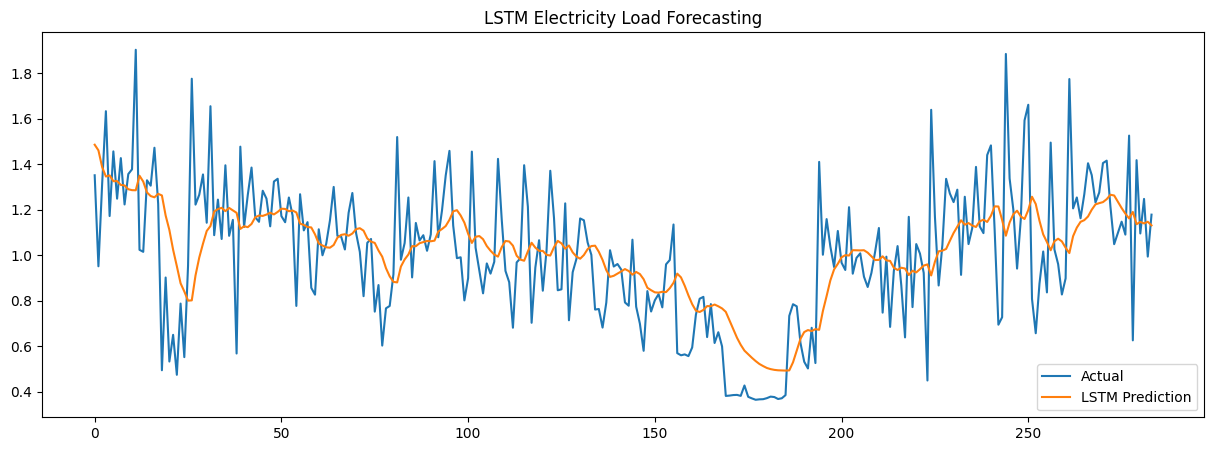

In [36]:
plt.figure(figsize=(15,5))
plt.plot(y_test_inv, label="Actual")
plt.plot(lstm_preds_inv, label="LSTM Prediction")
plt.legend()
plt.title("LSTM Electricity Load Forecasting")
plt.show()

In [38]:
model.save(f"{BASE_PATH}/models/lstm_model.keras")
import joblib
joblib.dump(scaler, f"{BASE_PATH}/models/scaler.pkl")

['/content/drive/MyDrive/electricity-load-system/models/scaler.pkl']